# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
|Jonathan Joyo Wibowo|5054251026|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OrdinalEncoder, LabelBinarizer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, auc, roc_curve

from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB

SEED = 67

In [ ]:
# Mount drive ke filesystem vm google collab, soalnya dataset di gdrive
uploaded = drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

In [ ]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

data = pd.read_csv("/content/drive/MyDrive/dataset/mushroom/mushrooms.csv")
data.head(30)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,e,c,s,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,e,e,s,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,s,m


In [ ]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print("Data Shape:", data.shape)
print("Data Info:\n", data.info())
print("Missing stalk-root Values:\n", data.groupby("stalk-root").count())

Data Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  s

In [ ]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
print(data.nunique())

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


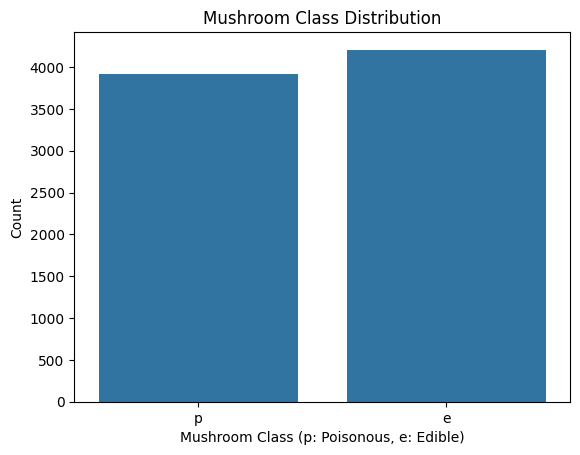

In [ ]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
sns.countplot(x="class", data=data)

plt.xlabel("Mushroom Class (p: Poisonous, e: Edible)")
plt.ylabel("Count")
plt.title("Mushroom Class Distribution")
plt.show()

In [1]:
features = [col for col in data.columns if col != "class"]
row, col = 11, 2

fig, axes = plt.subplots(nrows=row, ncols=col, figsize=(col * 10, row * 7))
axes = axes.flatten()

for i, column in enumerate(features):
  sns.countplot(x=column, data=data, ax=axes[i])
  axes[i].set_xlabel(column, fontsize=12)
  axes[i].set_ylabel("Count", fontsize=12)
  axes[i].tick_params(axis="both", labelsize=11)

for j in range(len(features), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [ ]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
class MissingStalkRootChanger(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy["stalk-root"] = data_copy["stalk-root"].replace("?", "m")
    return data_copy

In [ ]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
class VeilTypeDropper(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy = data_copy.drop(columns=["veil-type"], axis=1)
    return data_copy

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

#class_encoder = ColumnTransformer(transformers=[("encode_class", OrdinalEncoder(), ["class"])],
                                  #remainder="passthrough")

class ClassEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.ordinal_encoder = OrdinalEncoder(categories=[["e", "p"]])
    self.ordinal_encoder.fit(x[["class"]])
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy[["class"]] = self.ordinal_encoder.transform(data_copy[["class"]])
    return data_copy

In [ ]:
general_preprocessor = Pipeline([("missing_stalk_root", MissingStalkRootChanger()),
                                ("veil_type_dropper", VeilTypeDropper()),
                                ("class_encoder", ClassEncoder())])

In [ ]:
data = general_preprocessor.fit_transform(data)
data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1.0,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,w,o,p,k,s,u
1,0.0,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,w,o,p,n,n,g
2,0.0,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,w,o,p,n,n,m
3,1.0,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,w,o,p,k,s,u
4,0.0,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0.0,k,s,n,f,n,a,c,b,y,e,m,s,s,o,o,o,o,p,b,c,l
8120,0.0,x,s,n,f,n,a,c,b,y,e,m,s,s,o,o,n,o,p,b,v,l
8121,0.0,f,s,n,f,n,a,c,b,n,e,m,s,s,o,o,o,o,p,b,c,l
8122,1.0,k,y,n,f,y,f,c,n,b,t,m,s,k,w,w,w,o,e,w,v,l


In [ ]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_data, test_data = None, None

for train_idx, test_idx in split.split(data, data["class"]):
  train_data = data.iloc[train_idx]
  test_data = data.iloc[test_idx]

x_train, y_train = train_data.drop(columns=["class"], axis=1), train_data["class"]
x_test, y_test = test_data.drop(columns=["class"], axis=1), test_data["class"]

In [ ]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
class FeatureOrdinalEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.ordinal_encoder = OrdinalEncoder()
    self.ordinal_encoder.fit(x)
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy = self.ordinal_encoder.transform(data_copy)
    return data_copy

categorical_nb_preprocessor = Pipeline([("feature_ordinal_encoder", FeatureOrdinalEncoder())])

x_categorical_nb_train = categorical_nb_preprocessor.fit_transform(x_train)
x_categorical_nb_test = categorical_nb_preprocessor.transform(x_test)
y_categorical_nb_train = y_train.copy()
y_categorical_nb_test = y_test.copy()

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

class FeatureOneHotEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.one_hot_encoder = OneHotEncoder()
    self.one_hot_encoder.fit(x)
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy = self.one_hot_encoder.transform(data_copy)
    return data_copy


bernoulli_nb_preprocessor = Pipeline([("feature_one_hot_encoder", FeatureOneHotEncoder())])
multinomial_nb_preprocessor = Pipeline([("feature_one_hot_encoder", FeatureOneHotEncoder())])

x_bernoulli_nb_train = bernoulli_nb_preprocessor.fit_transform(x_train)
x_bernoulli_nb_test = bernoulli_nb_preprocessor.transform(x_test)
y_bernoulli_nb_train = y_train.copy()
y_bernoulli_nb_test = y_test.copy()

x_multinomial_nb_train = multinomial_nb_preprocessor.fit_transform(x_train)
x_multinomial_nb_test = multinomial_nb_preprocessor.transform(x_test)
y_multinomial_nb_train = y_train.copy()
y_multinomial_nb_test = y_test.copy()

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [ ]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
categorical_nb = CategoricalNB()
categorical_nb.fit(x_categorical_nb_train, y_categorical_nb_train)


CategoricalNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_categorical_nb = categorical_nb.predict(x_categorical_nb_test)
y_prob_categorical_nb = categorical_nb.predict_proba(x_categorical_nb_test)[:, 1]

accuracy_categorical_nb = accuracy_score(y_categorical_nb_test, y_pred_categorical_nb)
print("Categorical NB Accuracy:", accuracy_categorical_nb)

Categorical NB Accuracy: 0.9526153846153846


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(x_bernoulli_nb_train, y_bernoulli_nb_train)

BernoulliNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bernoulli_nb = bernoulli_nb.predict(x_bernoulli_nb_test)
y_prob_bernoulli_nb = bernoulli_nb.predict_proba(x_bernoulli_nb_test)[:, 1]

accuracy_bernoulli_nb = accuracy_score(y_bernoulli_nb_test, y_pred_bernoulli_nb)
print("Bernoulli NB Accuracy:", accuracy_bernoulli_nb)

Bernoulli NB Accuracy: 0.9433846153846154


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multinomial_nb = MultinomialNB()
multinomial_nb.fit(x_multinomial_nb_train, y_multinomial_nb_train)

MultinomialNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_multinomial_nb = multinomial_nb.predict(x_multinomial_nb_test)
y_prob_multinomial_nb = multinomial_nb.predict_proba(x_multinomial_nb_test)[:, 1]

accuracy_multinomial_nb = accuracy_score(y_multinomial_nb_test, y_pred_multinomial_nb)
print("Multinomial NB Accuracy:", accuracy_multinomial_nb)

Multinomial NB Accuracy: 0.9526153846153846


# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
models = {
    "Categorical NB": (y_categorical_nb_test, y_pred_categorical_nb),
    "Bernoulli NB": (y_bernoulli_nb_test, y_pred_bernoulli_nb),
    "Multinomial NB": (y_multinomial_nb_test, y_pred_multinomial_nb),
}

eval_matrices = []

for name, (y_true, y_pred) in models.items():
    eval_matrices.append({"Model": name,
                        "Accuracy": accuracy_score(y_true, y_pred),
                        "Precision": precision_score(y_true, y_pred),
                        "Recall": recall_score(y_true, y_pred),
                        "F1-Score": f1_score(y_true, y_pred)})

df_metrices = pd.DataFrame(eval_matrices)
df_metrices

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.952615,0.995787,0.905492,0.948495
1,Bernoulli NB,0.943385,0.987306,0.893997,0.938338
2,Multinomial NB,0.952615,0.995787,0.905492,0.948495


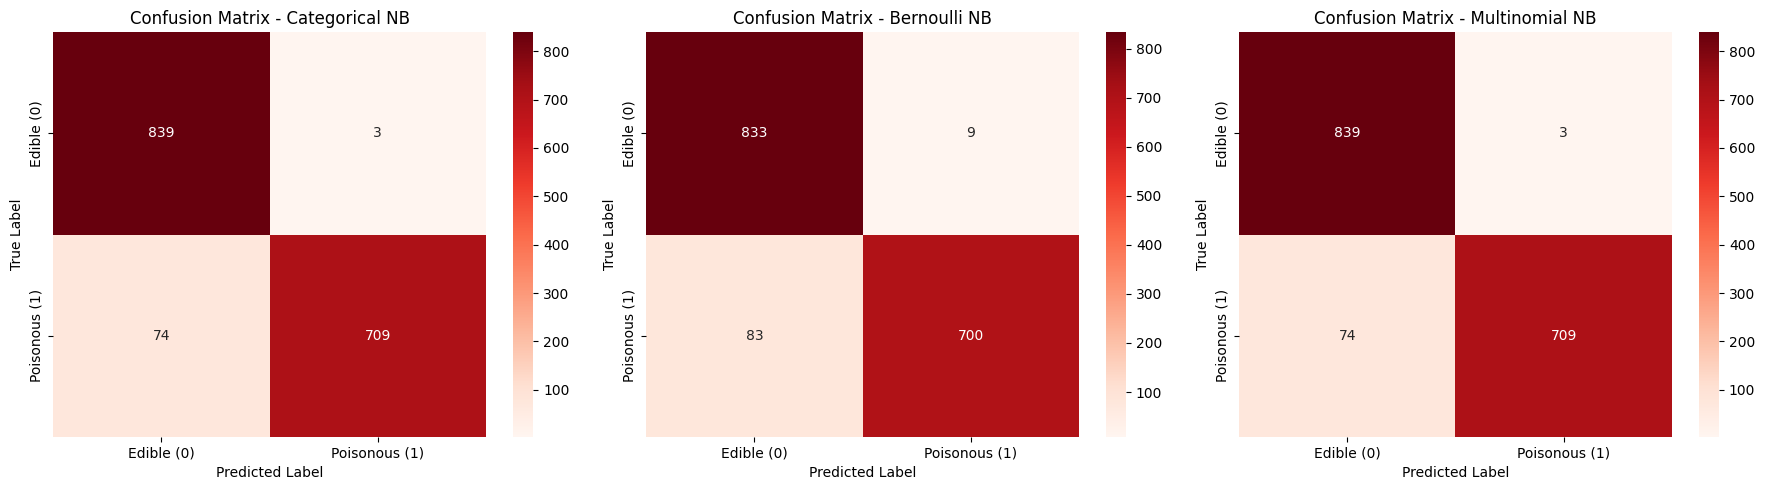

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (y_true, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds",
        ax=ax,
        xticklabels=["Edible (0)", "Poisonous (1)"],
        yticklabels=["Edible (0)", "Poisonous (1)"],
    )
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

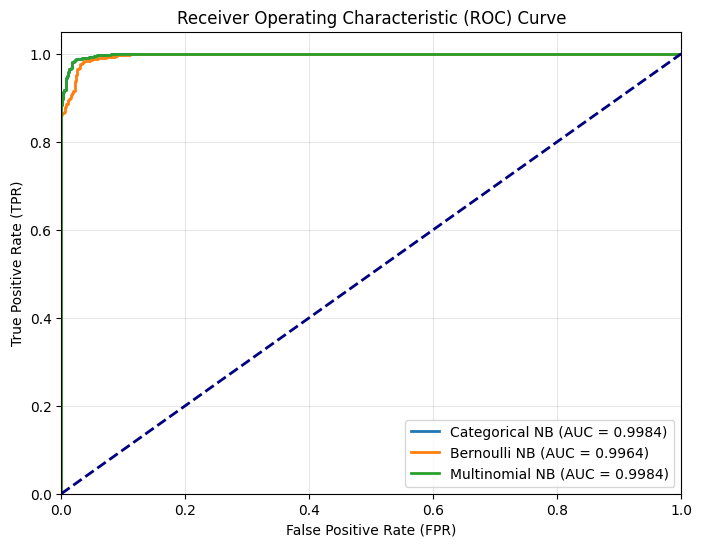

In [ ]:
probas = {"Categorical NB": (y_categorical_nb_test, y_prob_categorical_nb),
          "Bernoulli NB": (y_bernoulli_nb_test, y_prob_bernoulli_nb),
          "Multinomial NB": (y_multinomial_nb_test, y_prob_multinomial_nb)}

plt.figure(figsize=(8, 6))

for name, (y_true, y_prob) in probas.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

Dalam kasus ini Categorical NB dan Multinomial NB memberikan hasil prediksi yang sama akuratnya di ~95%, sedangkan Bernoulli NB memiliki akurasi sekitar ~93%

Ini membuktikan bahwa semua model Naive Bayes sangat bagus untuk dipakai dalam dataset ini

# 6. Kesimpulan dan Saran

Ketiga varian Naive Bayes (Categorical, Bernoulli, dan Multinomial) terbukti sangat efektif untuk mengklasifikasikan Mushroom Dataset dengan akurasi yang tinggi (semua di atas 93% dan AUC mendekati 1.00).

Untuk saran mungkin bisa dicoba untuk mengimputasi missing values pada stalk-root lalu dibandingkan hasilnya